# 14. Statistical Decision Analysis and Value of Information

Statistical inference tells us what parameter values remain plausible after seeing data. Decision analysis asks a different question: **what should we do, given that uncertainty and the consequences attached to each action?** We turn posterior uncertainty into expected value, regret, certainty equivalents, and the value of collecting more evidence.


## Learning Objectives

After working through this lecture, you should be able to:

- distinguish statistical estimation from decision optimization,
- write an expected-value or expected-utility decision rule,
- compare actions using posterior expected value, downside risk, and regret,
- understand why risk-neutral and risk-averse decision-makers may choose differently,
- compute and interpret the expected value of perfect information (EVPI),
- evaluate the expected value of sample information (EVSI) for a proposed follow-up study.


In [1]:
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# Keep table output readable in both Jupyter and Quarto-rendered HTML.
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 90)

# Use a restrained visual style that keeps uncertainty intervals and thresholds legible.
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5.8)
plt.rcParams["axes.titleweight"] = "bold"
warnings.filterwarnings("ignore", category=FutureWarning)

rng = np.random.default_rng(42)

COLORS = {
    "none": "#64748b",
    "enterprise": "#2563eb",
    "both": "#0f766e",
    "mid": "#7c3aed",
    "accent": "#d97706",
}


def posterior_normal_known_sigma(prior_mean, prior_sd, sample_mean, sigma, n):
    """Compute the conjugate normal posterior for a segment-level mean uplift.

    Parameters
    ----------
    prior_mean : float
        Prior mean of the segment uplift, measured in thousands of dollars per account.
    prior_sd : float
        Prior standard deviation for the segment uplift, in the same units as the mean.
    sample_mean : float
        Pilot estimate of the segment uplift from the observed study data.
    sigma : float
        Working standard deviation of account-level uplift around the segment mean.
    n : int
        Number of pilot observations used for the segment estimate.

    Returns
    -------
    tuple[float, float]
        Posterior mean and posterior standard deviation for the segment uplift.

    Idea
    ----
    The posterior mean is a precision-weighted compromise between the prior and the
    pilot mean. Larger pilots or lower measurement noise pull the result toward the data.
    """
    prior_precision = 1 / prior_sd**2
    data_precision = n / sigma**2
    posterior_sd = math.sqrt(1 / (prior_precision + data_precision))
    posterior_mean = posterior_sd**2 * (prior_precision * prior_mean + data_precision * sample_mean)
    return posterior_mean, posterior_sd


def certainty_equivalent(payoffs, risk_tolerance):
    """Convert simulated net values into a CARA certainty equivalent.

    Parameters
    ----------
    payoffs : array-like
        Simulated net-value draws, measured in millions of dollars.
    risk_tolerance : float
        Risk tolerance in millions of dollars. Higher values imply less downside aversion.
        Use ``np.inf`` for the risk-neutral benchmark.

    Returns
    -------
    float
        The guaranteed payoff that gives the same expected exponential utility as the
        uncertain payoff distribution.

    Idea
    ----
    This compresses both the expected payoff and the downside tail into one decision metric.
    A distribution with attractive average value can still have a low certainty equivalent.
    """
    payoffs = np.asarray(payoffs, dtype=float)
    if np.isinf(risk_tolerance):
        return float(payoffs.mean())
    shifted = payoffs - payoffs.max()
    expected_utility = np.exp(-shifted / risk_tolerance).mean()
    return float(payoffs.max() - risk_tolerance * np.log(expected_utility))

## 1. From Statistical Inference to Action

Statistical decision theory formalizes the move from uncertainty to action by combining:

1. a probability model for uncertain quantities,
2. a payoff, utility, or loss function,
3. an action rule that optimizes expected consequences.

In expected-utility form, the decision rule is

$$
a^* = \arg\max_a \; \mathbb{E}_{\theta}[u(V(a, \theta))],
$$

where:

- $a$ is an action,
- $\theta$ denotes uncertain parameters or states of the world,
- $V(a, \theta)$ is the value generated by action $a$ if the world is in state $\theta$,
- $u(\cdot)$ is a utility function.

When utility is linear, the rule reduces to choosing the action with the largest **posterior expected value**. When the decision-maker is risk-averse, the same posterior can lead to a different choice because downside outcomes receive more weight. This decision-theoretic framing is one of the key bridges between inference and action (Williams & Hooten, 2016; Strayhorn et al., 2024).

Value-of-information (VOI) analysis extends that logic one step further: it asks whether additional evidence is worth paying for. VOI treats information as valuable because it can reduce the expected cost of making the wrong decision under uncertainty (Tuffaha et al., 2014; Rothery et al., 2020).


## 2. Case Study: Segment-Specific Rollout of an AI Review Workflow

A subscription business has piloted an **AI-assisted account review workflow** meant to improve renewal outcomes for accounts at elevated churn risk. Leadership now needs to choose among three actions for next quarter:

- **No rollout**
- **Enterprise-only rollout**
- **Enterprise + Mid-market rollout**

The pilot produced segment-specific estimates of incremental renewal margin per eligible account, measured in **thousands of dollars**.

The enterprise segment looks strongly promising. The mid-market segment is more ambiguous: its posterior mean is positive, but the effect is close to the cost threshold and still uncertain.

### Variable Guide

| Variable | Meaning | Why it matters |
| --- | --- | --- |
| `tau_enterprise` | Incremental renewal margin per enterprise account (USD thousands) | Core uncertain uplift for enterprise rollout |
| `tau_mid` | Incremental renewal margin per mid-market account (USD thousands) | Core uncertain uplift for the marginal rollout decision |
| `cost_enterprise` | Operational cost per enterprise account (USD thousands) | Needed to convert uplift to net value |
| `cost_mid` | Operational cost per mid-market account (USD thousands) | The profitability threshold for mid-market expansion |
| `overhead_both` | Extra coordination overhead if both segments are rolled out (USD millions) | Represents tooling, staffing, and governance complexity |
| `N_enterprise`, `N_mid` | Number of eligible accounts next quarter | Scales per-account uncertainty into business-scale consequences |


In [2]:
# Build segment-level pilot evidence and translate it into posterior distributions.
rollout_overhead_m = 0.15
segment_data = pd.DataFrame(
    [
        {
            "segment": "Enterprise",
            "accounts": 320,
            "prior_mean": 3.2,
            "prior_sd": 1.4,
            "pilot_mean": 4.9,
            "sigma": 9.5,
            "cost": 2.2,
            "deployable_accounts": 350,
        },
        {
            "segment": "Mid-market",
            "accounts": 240,
            "prior_mean": 1.0,
            "prior_sd": 1.2,
            "pilot_mean": 1.8,
            "sigma": 11.0,
            "cost": 1.3,
            "deployable_accounts": 900,
        },
    ]
)

# For each segment, update the uncertain uplift and summarize the chance that uplift clears cost.
posterior_rows = []
for row in segment_data.itertuples(index=False):
    post_mean, post_sd = posterior_normal_known_sigma(
        prior_mean=row.prior_mean,
        prior_sd=row.prior_sd,
        sample_mean=row.pilot_mean,
        sigma=row.sigma,
        n=row.accounts,
    )
    posterior_rows.append(
        {
            "segment": row.segment,
            "posterior_mean_uplift_k": post_mean,
            "posterior_sd_uplift_k": post_sd,
            "cost_k": row.cost,
            "deployable_accounts": row.deployable_accounts,
            "prob_net_positive": float(1 - pd.Series(rng.normal(post_mean, post_sd, 200_000)).lt(row.cost).mean()),
        }
    )

posterior_summary = pd.DataFrame(posterior_rows)
display(posterior_summary.round(3))

,segment,posterior_mean_uplift_k,posterior_sd_uplift_k,cost_k,deployable_accounts,prob_net_positive
0,Enterprise,4.686,0.497,2.2,350,1.000
1,Mid-market,1.593,0.611,1.3,900,0.685


The pilot results already suggest a decision asymmetry:

- enterprise uplift is well above its cost threshold,
- mid-market uplift is only modestly above its threshold and still uncertain.

That asymmetry is exactly what creates a meaningful value-of-information problem. If both segments were obviously profitable or obviously unprofitable, there would be little value in further analysis.

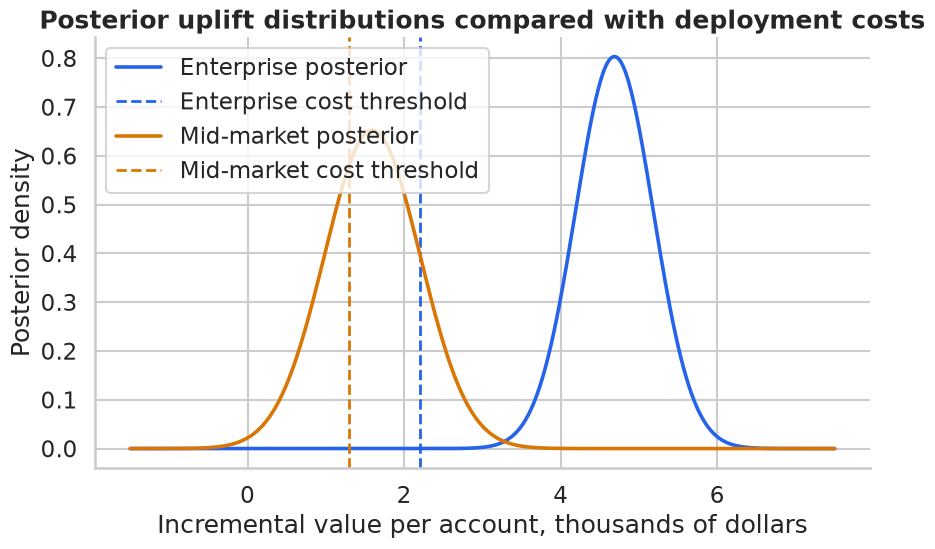

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.6))

# Plot posterior uplift distributions and show each segment's cost threshold on the same axis.
segment_colors = {"Enterprise": COLORS["enterprise"], "Mid-market": COLORS["accent"]}
x_grid = np.linspace(-1.5, 7.5, 500)
for row in posterior_summary.itertuples(index=False):
    color = segment_colors[row.segment]
    density = (1 / (row.posterior_sd_uplift_k * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x_grid - row.posterior_mean_uplift_k) / row.posterior_sd_uplift_k) ** 2
    )
    ax.plot(x_grid, density, linewidth=2.6, color=color, label=f"{row.segment} posterior")
    ax.axvline(row.cost_k, color=color, linestyle="--", linewidth=2, label=f"{row.segment} cost threshold")

ax.set_title("Posterior uplift distributions compared with deployment costs")
ax.set_xlabel("Incremental value per account, thousands of dollars")
ax.set_ylabel("Posterior density")
ax.legend(loc="upper left", frameon=True)
sns.despine()
plt.show()

## 3. Action Values Under a Risk-Neutral Rule

We work in **millions of dollars** for total next-quarter value. Let

- $N_E = 350$ and $N_M = 900$ be the segment sizes,
- $c_E = 2.2$ and $c_M = 1.3$ be rollout costs in USD thousands per account,
- $h = 0.15$ be an extra cross-segment rollout overhead in USD millions.

The action values are:

$$
V_{\text{none}} = 0,
$$

$$
V_{E} = \frac{N_E(\tau_E - c_E)}{1000},
$$

$$
V_{E+M} = V_E + \frac{N_M(\tau_M - c_M)}{1000} - h.
$$

A risk-neutral decision-maker chooses the action with the largest posterior expected value.


In [4]:
n_draws = 120_000

# Simulate posterior uncertainty in deployable value for the two uncertain rollout segments.
posterior_draws = {}
for row in posterior_summary.itertuples(index=False):
    uplift_draws = rng.normal(row.posterior_mean_uplift_k, row.posterior_sd_uplift_k, n_draws)
    net_per_account_k = uplift_draws - row.cost_k
    posterior_draws[row.segment] = net_per_account_k * row.deployable_accounts / 1_000

enterprise_value = posterior_draws["Enterprise"]
midmarket_value = posterior_draws["Mid-market"]
no_rollout = np.zeros(n_draws)

# Compare feasible actions under each draw from the posterior predictive distribution.
actions = {
    "No rollout": no_rollout,
    "Enterprise only": enterprise_value,
    "Enterprise + Mid-market": enterprise_value + midmarket_value - rollout_overhead_m,
}
values = pd.DataFrame(actions)

best_by_draw = np.maximum.reduce(list(actions.values()))
action_summary_rows = []
for action, draws in actions.items():
    regret = best_by_draw - draws
    action_summary_rows.append(
        {
            "action": action,
            "expected_net_value_m": draws.mean(),
            "p10_m": np.quantile(draws, 0.10),
            "p90_m": np.quantile(draws, 0.90),
            "prob_negative_value": (draws < 0).mean(),
            "prob_action_is_optimal": (np.isclose(draws, best_by_draw)).mean(),
            "expected_regret_m": regret.mean(),
        }
    )

action_summary = pd.DataFrame(action_summary_rows).sort_values("expected_net_value_m", ascending=False)
display(action_summary.round(3))

,action,expected_net_value_m,p10_m,p90_m,prob_negative_value,prob_action_is_optimal,expected_regret_m
2,Enterprise + Mid-market,0.98,0.242,1.715,0.045,0.581,0.169
1,Enterprise only,0.87,0.647,1.092,0.000,0.419,0.279
0,No rollout,0.00,0.000,0.000,0.000,0.000,1.149


The risk-neutral rule favors rolling out to both Enterprise and Mid-market accounts. The important detail is that the recommendation is not equally secure across actions. Enterprise-only rollout has lower mean value, but it has almost no downside in the posterior simulation. Adding Mid-market raises expected value while introducing a visible chance of negative total value and more posterior regret when that segment underperforms.

That is exactly why decision analysis belongs after estimation. A posterior mean answers what looks best on average. A decision table asks whether the extra expected value is worth the extra downside risk and whether the remaining uncertainty is expensive enough to justify more data.

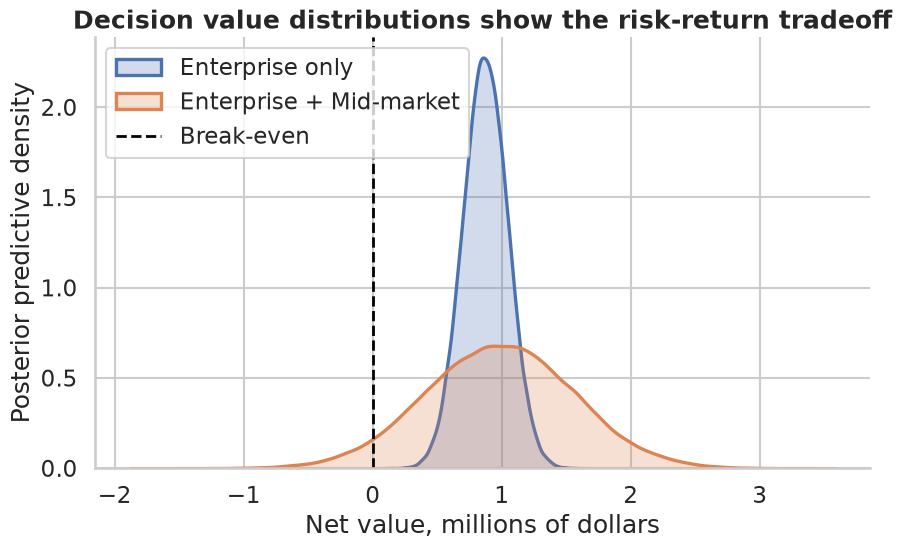

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.6))

# Plot the two plausible deployment choices separately so the legend stays explicit.
plot_actions = {
    "Enterprise only": enterprise_value,
    "Enterprise + Mid-market": enterprise_value + midmarket_value - rollout_overhead_m,
}
for action, draws in plot_actions.items():
    sns.kdeplot(draws, fill=True, alpha=0.25, linewidth=2.4, label=action, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=2, label="Break-even")
ax.set_title("Decision value distributions show the risk-return tradeoff")
ax.set_xlabel("Net value, millions of dollars")
ax.set_ylabel("Posterior predictive density")
ax.legend(frameon=True)
sns.despine()
plt.show()

Under a purely risk-neutral rule, the largest posterior expected value comes from **Enterprise + Mid-market**. But the distribution plot shows why that conclusion is not the end of the story:

- the enterprise-only action has almost no chance of a negative quarter,
- the full rollout has a noticeably larger negative tail,
- the mid-market decision is carrying most of that extra risk.

This is where utility enters. If stakeholders care about the mean and downside exposure, the preferred action may change.

## 4. Risk Aversion and Certainty Equivalents

A common way to model risk aversion is with a constant-absolute-risk-aversion (CARA) utility:

$$
u(x) = 1 - \exp(-x / R),
$$

where $R$ is a **risk tolerance** measured here in millions of dollars. Smaller $R$ means stronger dislike of downside volatility.

For each action we compute the **certainty equivalent (CE)**:

$$
CE(a) = -R \log \mathbb{E}[\exp(-V(a, \theta)/R)].
$$

The certainty equivalent is the guaranteed amount of money a decision-maker would consider equivalent to the uncertain action.


In [6]:
# Build a summary table that supports the interpretation in the surrounding notes.
risk_tolerances = np.array([0.15, 0.20, 0.25, 0.35, 0.50, 0.75, 1.00, np.inf])

ce_rows = []
for R in risk_tolerances:
    label = "Risk-neutral" if np.isinf(R) else f"{R:.2f}"
    for action in values.columns:
        ce_rows.append(
            {
                "risk_tolerance_m": label,
                "action": action,
                "certainty_equivalent_m": certainty_equivalent(values[action].to_numpy(), R),
            }
        )

ce_table = pd.DataFrame(ce_rows)
ce_pivot = ce_table.pivot(index="risk_tolerance_m", columns="action", values="certainty_equivalent_m").reset_index()

numeric_cols = [col for col in ce_pivot.columns if col != "risk_tolerance_m"]
ce_pivot[numeric_cols] = ce_pivot[numeric_cols].mask(np.isclose(ce_pivot[numeric_cols], 0.0), 0.0)

display(ce_pivot.round(3))


action,risk_tolerance_m,Enterprise + Mid-market,Enterprise only,No rollout
0,0.15,-0.161,0.769,0.0
1,0.20,0.121,0.794,0.0
2,0.25,0.298,0.809,0.0
3,0.35,0.497,0.826,0.0
4,0.50,0.644,0.839,0.0
5,0.75,0.756,0.850,0.0
6,1.00,0.813,0.855,0.0
7,Risk-neutral,0.980,0.870,0.0


The certainty-equivalent table shows how the recommendation changes when downside losses matter. At very low risk tolerance, the combined rollout is unattractive even though its average value is highest. Enterprise-only rollout keeps more of its value because its posterior distribution is narrower and largely above break-even.

The Mid-market implication is caution. The decision has moved from “estimate the uplift” to “decide whether we need more information, a smaller launch, or stronger guardrails before accepting the tail risk.”

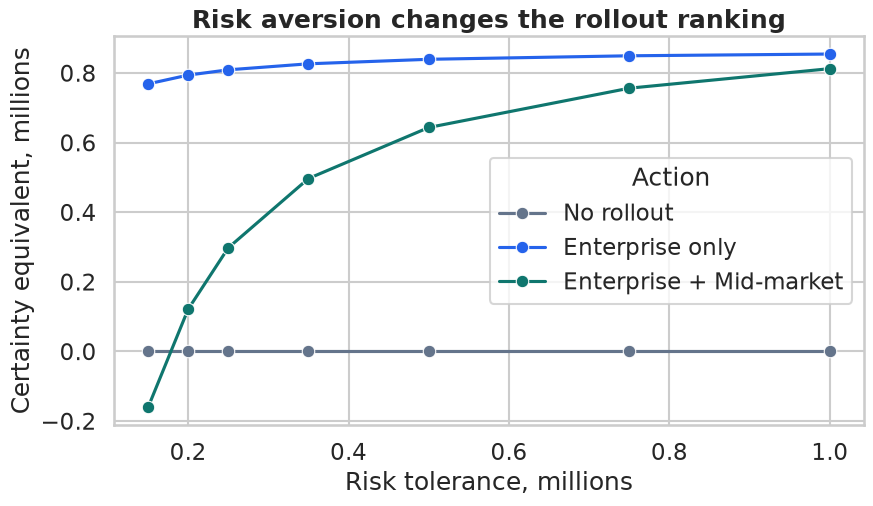

In [7]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
ce_plot = ce_table.loc[ce_table["risk_tolerance_m"] != "Risk-neutral"].copy()
ce_plot["risk_tolerance_m"] = ce_plot["risk_tolerance_m"].astype(float)

fig, ax = plt.subplots(figsize=(10, 5.4))
sns.lineplot(
    data=ce_plot,
    x="risk_tolerance_m",
    y="certainty_equivalent_m",
    hue="action",
    marker="o",
    palette=[COLORS["none"], COLORS["enterprise"], COLORS["both"]],
    ax=ax,
)
ax.set_title("Risk aversion changes the rollout ranking")
ax.set_xlabel("Risk tolerance, millions")
ax.set_ylabel("Certainty equivalent, millions")
ax.legend(title="Action", frameon=True, loc="center right")
fig.subplots_adjust(left=0.23, right=0.98, bottom=0.16, top=0.88)
plt.show()

This is a good example of why “best expected value” is not the same thing as “best decision” in every organization.

- A risk-neutral planner prefers **Enterprise + Mid-market** because its expected value is highest.
- A more downside-sensitive planner can prefer **Enterprise only**, because the incremental mean gain from mid-market does not adequately compensate for the volatility it adds.

Decision analysis makes that tradeoff explicit.

## 5. The Expected Value of Perfect Information

The **expected value of perfect information (EVPI)** asks:

> How much would we gain, on average, if uncertainty were resolved before choosing the action?

Under linear value, EVPI is

$$
EVPI = \mathbb{E}_{\theta}\left[\max_a V(a, \theta)\right]
-
\max_a \mathbb{E}_{\theta}[V(a, \theta)].
$$

EVPI is always nonnegative. It is an upper bound on the value of any real study because no practical study can deliver literally perfect information (Rothery et al., 2020; Tuffaha et al., 2014).

We also compute a segment-specific perfect-information quantity for enterprise versus mid-market uncertainty. That is conceptually similar to **partial perfect information**: it helps identify where additional information would matter most.


In [8]:
# EVPI compares the best action after uncertainty is revealed with the best action today.
current_best_ev = max(draws.mean() for draws in actions.values())
perfect_information_value = best_by_draw.mean()
evpi_total = perfect_information_value - current_best_ev

# Segment-specific EVPIs reveal which uncertainty is actually driving the value of learning.
enterprise_known_actions = {
    "No rollout": np.zeros(n_draws),
    "Enterprise only": enterprise_value,
    "Enterprise + Mid-market expected": enterprise_value + midmarket_value.mean() - rollout_overhead_m,
}
evpi_enterprise = np.maximum.reduce(list(enterprise_known_actions.values())).mean() - current_best_ev

midmarket_known_actions = {
    "No rollout": np.zeros(n_draws),
    "Enterprise expected only": np.full(n_draws, enterprise_value.mean()),
    "Enterprise expected + Mid-market": enterprise_value.mean() + midmarket_value - rollout_overhead_m,
}
evpi_midmarket = np.maximum.reduce(list(midmarket_known_actions.values())).mean() - current_best_ev

voi_table = pd.DataFrame(
    [
        {"information_quantity": "All remaining uncertainty", "value_m": evpi_total},
        {"information_quantity": "Mid-market perfect information", "value_m": evpi_midmarket},
        {"information_quantity": "Enterprise perfect information", "value_m": evpi_enterprise},
    ]
)
voi_table["value_m"] = voi_table["value_m"].mask(np.isclose(voi_table["value_m"], 0.0, atol=1e-8), 0.0)

display(voi_table.round(3))

,information_quantity,value_m
0,All remaining uncertainty,0.169
1,Mid-market perfect information,0.169
2,Enterprise perfect information,0.000


The value of perfect information is concentrated in the Mid-market segment. Enterprise uncertainty has essentially zero incremental value because the current decision to serve Enterprise accounts is already stable across the posterior draws. Mid-market is different. Sometimes it is worth including, and sometimes it is the source of regret.

This is useful operationally. It says the next learning budget should not be spent on a broad “more data” request. It should target the uncertain segment that can change the action.

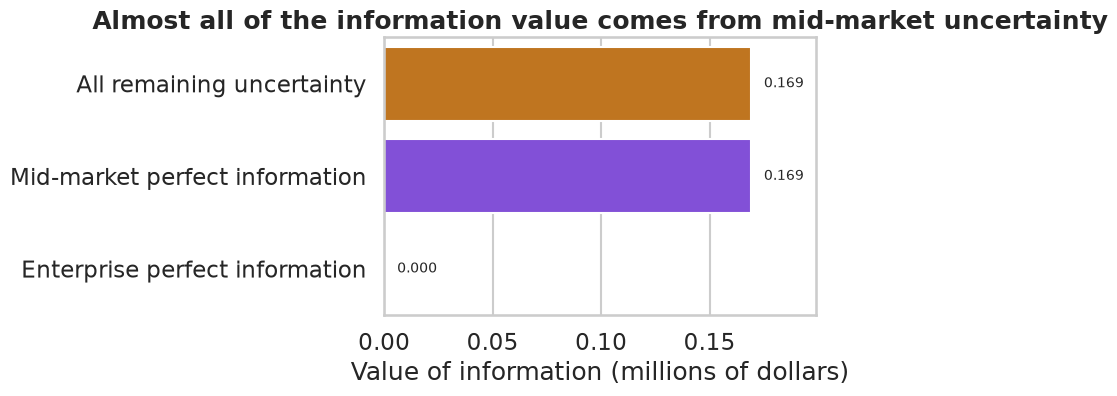

In [9]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
fig, ax = plt.subplots(figsize=(8.6, 4.3))
sns.barplot(
    data=voi_table,
    x="value_m",
    y="information_quantity",
    hue="information_quantity",
    dodge=False,
    palette=[COLORS["accent"], COLORS["mid"], COLORS["enterprise"]],
    legend=False,
    ax=ax,
)
ax.set_title("Almost all of the information value comes from mid-market uncertainty")
ax.set_xlabel("Value of information (millions of dollars)")
ax.set_ylabel("")

for patch, (_, row) in zip(ax.patches, voi_table.iterrows()):
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    x = width + 0.006 if width > 0 else 0.006
    ax.text(x, y, f"{row['value_m']:.3f}", va="center", ha="left", fontsize=10)

ax.set_xlim(0, max(voi_table["value_m"]) + 0.03)
plt.tight_layout()
plt.show()


The decomposition is the useful part. Enterprise uncertainty contributes very little information value because the enterprise rollout is already a robust choice. Mid-market uncertainty contributes almost all of the value because it is the uncertainty that can still change the action.

That is the practical interpretation of VOI. It prices how much uncertainty matters for action. It tells us **which uncertainty is decision-relevant**.

## 6. The Expected Value of a New Mid-Market Pilot

Perfect information is unattainable, so we next ask whether a real follow-up study is worthwhile.

Suppose the organization can run a new **mid-market pilot** with sample size $n$. We assume:

- the future study measures the same segment-level uplift quantity,
- the per-account outcome noise remains $\sigma = 11$ thousand dollars,
- the current posterior for mid-market uplift acts as the prior for the follow-up design.

The **expected value of sample information (EVSI)** for a design of size $n$ is:

$$
EVSI_n
=
\mathbb{E}_{Y_n}
\left[
\max_a \mathbb{E}[V(a, \theta) \mid Y_n]
\right]
-
\max_a \mathbb{E}[V(a, \theta)].
$$

We then compare that gross information value with the direct research cost of the study.


In [10]:
sample_sizes = np.array([40, 80, 120, 200, 320, 500, 800])
fixed_cost_m = 0.015
variable_cost_m = 0.00022

# The proposed study only improves the Mid-market posterior standard deviation.
evsi_rows = []
for n_new in sample_sizes:
    current_sd = posterior_summary.loc[posterior_summary["segment"].eq("Mid-market"), "posterior_sd_uplift_k"].iloc[0]
    sigma = segment_data.loc[segment_data["segment"].eq("Mid-market"), "sigma"].iloc[0]
    updated_sd = math.sqrt(1 / (1 / current_sd**2 + n_new / sigma**2))

    # Approximate EVSI by simulating future posterior means after the new pilot.
    midmarket_posterior_mean = posterior_summary.loc[
        posterior_summary["segment"].eq("Mid-market"), "posterior_mean_uplift_k"
    ].iloc[0]
    future_mean_sd = math.sqrt(max(current_sd**2 - updated_sd**2, 0))
    future_means = rng.normal(midmarket_posterior_mean, future_mean_sd, n_draws)
    future_midmarket_expected_value = (
        future_means - segment_data.loc[segment_data["segment"].eq("Mid-market"), "cost"].iloc[0]
    ) * segment_data.loc[segment_data["segment"].eq("Mid-market"), "deployable_accounts"].iloc[0] / 1_000

    future_best = np.maximum.reduce(
        [
            np.zeros(n_draws),
            np.full(n_draws, enterprise_value.mean()),
            np.full(n_draws, enterprise_value.mean()) + future_midmarket_expected_value - rollout_overhead_m,
        ]
    )
    gross_evsi = future_best.mean() - current_best_ev
    study_cost = fixed_cost_m + variable_cost_m * n_new
    evsi_rows.append(
        {
            "new_pilot_accounts": n_new,
            "gross_evsi_m": gross_evsi,
            "study_cost_m": study_cost,
            "net_evsi_m": gross_evsi - study_cost,
        }
    )

evsi_table = pd.DataFrame(evsi_rows)
display(evsi_table.round(3))

,new_pilot_accounts,gross_evsi_m,study_cost_m,net_evsi_m
0,40,0.033,0.024,0.009
1,80,0.054,0.033,0.022
2,120,0.070,0.041,0.029
3,200,0.090,0.059,0.031
4,320,0.108,0.085,0.022
5,500,0.125,0.125,-0.000
6,800,0.136,0.191,-0.055


The expected value of sample information rises as the follow-up pilot becomes more informative, but the net value eventually peaks because study costs rise with sample size. The best design is therefore not “collect as much data as possible.” It is the pilot size that buys enough decision improvement without letting the research cost consume the learning value.

This is a practical lesson for analytics teams. A study design should be judged against the decision it can change, not only against the precision it can add.

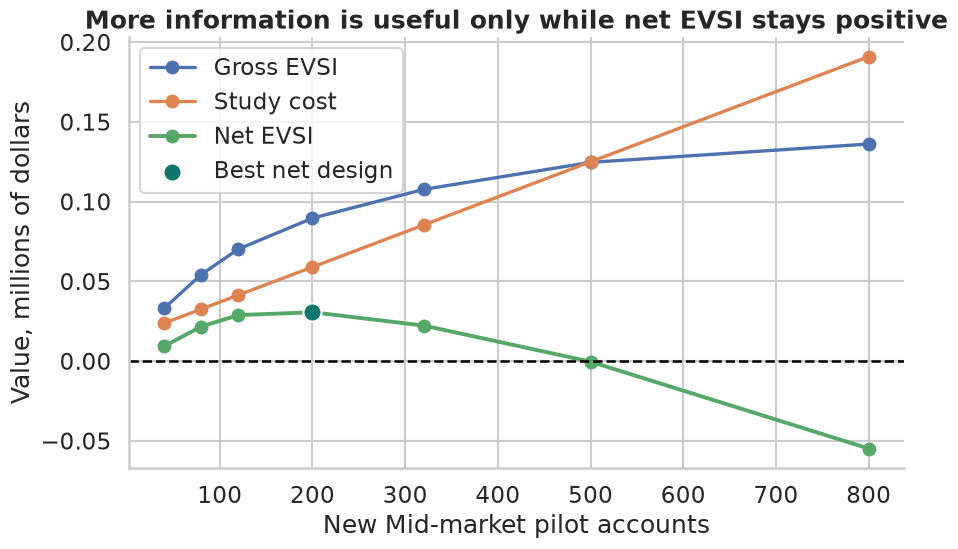

In [11]:
fig, ax = plt.subplots(figsize=(10, 5.6))

# Mark the design with the largest net EVSI so the operational recommendation is visible.
best_design = evsi_table.loc[evsi_table["net_evsi_m"].idxmax()]
ax.plot(evsi_table["new_pilot_accounts"], evsi_table["gross_evsi_m"], marker="o", linewidth=2.4, label="Gross EVSI")
ax.plot(evsi_table["new_pilot_accounts"], evsi_table["study_cost_m"], marker="o", linewidth=2.4, label="Study cost")
ax.plot(evsi_table["new_pilot_accounts"], evsi_table["net_evsi_m"], marker="o", linewidth=2.8, label="Net EVSI")
ax.scatter(
    [best_design["new_pilot_accounts"]],
    [best_design["net_evsi_m"]],
    s=170,
    color="#0f766e",
    edgecolor="white",
    linewidth=1.5,
    zorder=5,
    label="Best net design",
)
ax.axhline(0, color="black", linestyle="--", linewidth=1.8)
ax.set_title("More information is useful only while net EVSI stays positive")
ax.set_xlabel("New Mid-market pilot accounts")
ax.set_ylabel("Value, millions of dollars")
ax.legend(frameon=True)
sns.despine()
plt.show()

This section is the practical endgame of VOI.

- Small studies do not reduce enough uncertainty.
- Very large studies reduce more uncertainty, but their cost eventually overwhelms the incremental gain.
- The best design is therefore a compromise between learning and spending.

In this simulation, the VOI logic says something quite specific: **enterprise rollout looks ready now, while mid-market research still has real decision value and should be sized deliberately.**

<!-- real-data-companion-course01 -->
## Real-Data Companion: Value of Information for a Cost-Sharing Decision

A decision analysis needs an action, an uncertain quantity, and a utility model. RAND HIE gives us a real utilization contrast between free care and cost sharing. The outcome is outpatient physician visits, and the contrast is based on cost-sharing assignment derived from `lncoins`.

The companion uses bootstrap uncertainty around the utilization contrast and then attaches an illustrative value model. That model translates extra visits into a decision quantity, net value per person, under explicit assumptions about the value of access and the program cost. The exact utility numbers are not historical facts from the experiment; they are teaching assumptions used to show the decision-analysis workflow.

The experiment asks how a recommendation changes when uncertainty is priced in decision terms. It is not a complete health-policy evaluation. It demonstrates how real data, a transparent utility model, and uncertainty propagation combine to produce a recommendation that stakeholders can challenge.

For clarity, the unit is a person-period record. The outcome is outpatient visit count, and the experiment translates the free-care versus cost-sharing contrast into a decision quantity under an explicit utility model. That utility model is illustrative and should be debated separately from the historical data.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

**RAND HIE decision quantities under an illustrative utility model**

,quantity,estimate
0,Mean extra visits under free care,0.578000
1,Mean net value under utility model,-0.111000
2,Probability net value is positive,0.000000
3,90% lower bound,-0.123000
4,90% upper bound,-0.098000


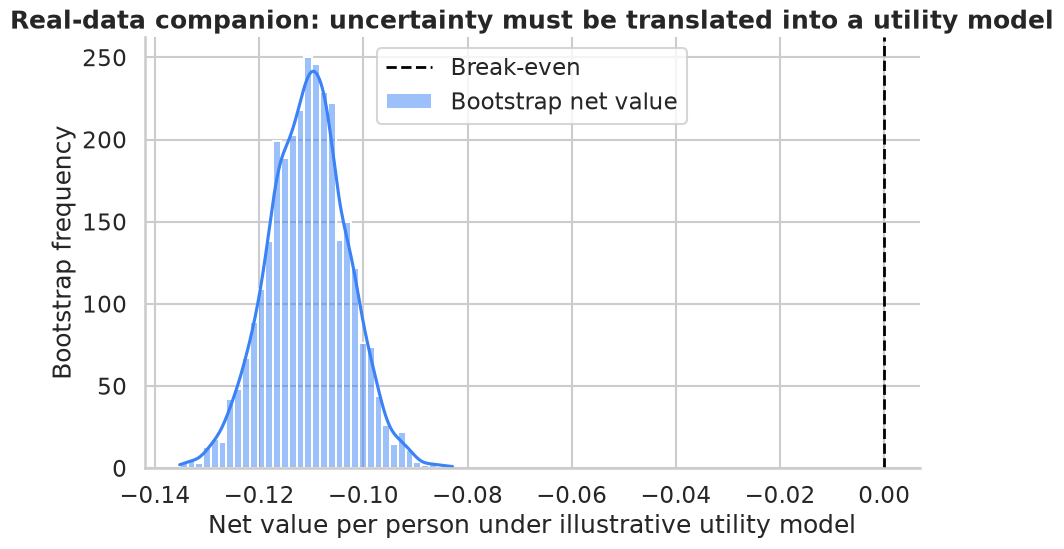

In [12]:
def _find_project_root(start_path):
    """Find the portfolio root by walking upward from the notebook location.

    Parameters
    ----------
    start_path : pathlib.Path
        Directory or file path used as the starting point for the upward search.

    Returns
    -------
    pathlib.Path
        The first ancestor containing ``pyproject.toml``. If none is found, the resolved
        starting directory is returned so relative imports still fail in an interpretable way.
    """
    path = Path(start_path).resolve()
    if path.is_file():
        path = path.parent
    for candidate in [path, *path.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return path

PROJECT_ROOT = _find_project_root(Path.cwd())
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie

# Use the RAND HIE as a compact real-data companion for decision analysis.
rand_df = load_statsmodels_randhie()
rand_work = rand_df[["lncoins", "mdvis", "idp", "physlm", "disea", "hlthg", "hlthf", "hlthp"]].dropna().copy()
rand_work["free_care"] = np.isclose(rand_work["lncoins"], 0.0).astype(int)

# Construct a deliberately simple utility model so the real-data example stays transparent.
value_per_visit = 0.12
program_cost = 0.18
baseline_visits = rand_work.loc[rand_work["free_care"].eq(0), "mdvis"].mean()
free_visits = rand_work.loc[rand_work["free_care"].eq(1), "mdvis"].mean()
observed_extra_visits = free_visits - baseline_visits

boot_values = []
for _ in range(3_000):
    sample = rand_work.sample(frac=1, replace=True, random_state=int(rng.integers(0, 1_000_000)))
    extra = sample.loc[sample["free_care"].eq(1), "mdvis"].mean() - sample.loc[sample["free_care"].eq(0), "mdvis"].mean()
    net_value = value_per_visit * extra - program_cost
    boot_values.append(net_value)
boot_values = np.array(boot_values)

rand_decision_summary = pd.DataFrame(
    [
        {"quantity": "Mean extra visits under free care", "estimate": observed_extra_visits},
        {"quantity": "Mean net value under utility model", "estimate": boot_values.mean()},
        {"quantity": "Probability net value is positive", "estimate": (boot_values > 0).mean()},
        {"quantity": "90% lower bound", "estimate": np.quantile(boot_values, 0.05)},
        {"quantity": "90% upper bound", "estimate": np.quantile(boot_values, 0.95)},
    ]
)

display(Markdown("**RAND HIE decision quantities under an illustrative utility model**"))
smart_display(rand_decision_summary.round(3))

fig, ax = plt.subplots(figsize=(10, 5.6))
sns.histplot(boot_values, bins=35, kde=True, ax=ax, color="#3b82f6", label="Bootstrap net value")
ax.axvline(0, color="black", linestyle="--", linewidth=2, label="Break-even")
ax.set_title("Real-data companion: uncertainty must be translated into a utility model")
ax.set_xlabel("Net value per person under illustrative utility model")
ax.set_ylabel("Bootstrap frequency")
ax.legend(frameon=True)
sns.despine()
plt.show()

The RAND HIE companion is not meant to settle health policy. It shows how the same decision-analysis grammar applies once real data enter the discussion. We must define an action, choose a utility model, propagate statistical uncertainty, and then ask whether the action has positive decision value.

Under the deliberately simple utility assumptions above, free care creates additional utilization, but the assumed program cost is large enough that the net value distribution remains negative. The policy lesson is not that the historical experiment has a universal negative answer. The lesson is that a decision recommendation depends on the chosen welfare weights, cost assumptions, and uncertainty propagation. Those assumptions should be explicit enough for stakeholders to challenge.

## What to Remember

- A confidence interval or posterior distribution is not yet a decision; a decision also needs a payoff or loss structure.
- Risk-neutral expected value and risk-averse expected utility can recommend different actions from the same posterior.
- Regret is often a useful complement to expected value because it quantifies the cost of being wrong ex post.
- EVPI measures the maximum possible value of eliminating uncertainty; no real study should be worth more than EVPI.
- Segment-specific or parameter-specific information values help identify which uncertainty actually matters for the action.
- EVSI is the bridge from “there is uncertainty” to “this particular follow-up study is or is not worth funding.”

In the next notebook, we translate this kind of analysis into stakeholder-ready recommendations, memos, and technical appendices.


## References

- Rothery, C., Strong, M., Koffijberg, H., et al. (2020). *Value of information analytical methods: Report 2 of the ISPOR Value of Information Analysis Emerging Good Practices Task Force.* *Value in Health, 23*(3), 277-286. [https://doi.org/10.1016/j.jval.2020.01.004](https://doi.org/10.1016/j.jval.2020.01.004)
- Strayhorn, J. C., Collins, L. M., & Vanness, D. J. (2024). *A posterior expected value approach to decision-making in the multiphase optimization strategy for intervention science.* *Psychological Methods, 29*(4), 656-678. [https://doi.org/10.1037/met0000569](https://doi.org/10.1037/met0000569)
- Tuffaha, H., Gordon, L. G., & Scuffham, P. (2014). *Value of information analysis in healthcare: a review of principles and applications.* *Journal of Medical Economics, 17*(6), 377-383. [https://doi.org/10.3111/13696998.2014.907170](https://doi.org/10.3111/13696998.2014.907170)
- Welton, N. J., & Thom, H. (2015). *Value of information.* *Medical Decision Making, 35*(5), 564-566. [https://doi.org/10.1177/0272989X15579164](https://doi.org/10.1177/0272989X15579164)
- Williams, P. J., & Hooten, M. B. (2016). *Combining statistical inference and decisions in ecology.* *Ecological Applications, 26*(6), 1930-1942. [https://doi.org/10.1890/15-1593.1](https://doi.org/10.1890/15-1593.1)
